In [ ]:
!pip install gdown

In [ ]:
import gdown

file_id = "1Um4KsDZUlnERL2uSHtUd-6_DngA8HY0n"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "dataset.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1Um4KsDZUlnERL2uSHtUd-6_DngA8HY0n
From (redirected): https://drive.google.com/uc?id=1Um4KsDZUlnERL2uSHtUd-6_DngA8HY0n&confirm=t&uuid=67c60124-2622-4d84-844c-85457d542668
To: /content/dataset.zip
100%|██████████| 124M/124M [00:00<00:00, 250MB/s] 


'dataset.zip'

In [ ]:

!unzip dataset.zip -d /content/dataset

Archive:  dataset.zip
replace /content/dataset/sample_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/sample_submission.csv  
replace /content/dataset/test_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/test_identity.csv  
replace /content/dataset/test_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/test_transaction.csv  
replace /content/dataset/train_identity.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/train_identity.csv  
replace /content/dataset/train_transaction.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dataset/train_transaction.csv  


In [ ]:
import pandas as pd

train_identity = pd.read_csv("/content/dataset/train_identity.csv")
train_transaction = pd.read_csv("/content/dataset/train_transaction.csv")

In [ ]:
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

In [ ]:
for i in train.columns:
    print(i,'NaN values present is:',train[i].isnull().sum(),end=" ")
    print('Data type:',train[i].dtypes,end=" ")
    print(" % of Missing data = ", "%.2f%%" % (train[i].isnull().sum()/train.shape[0]*100))

TransactionID NaN values present is: 0 Data type: int64  % of Missing data =  0.00%
isFraud NaN values present is: 0 Data type: int64  % of Missing data =  0.00%
TransactionDT NaN values present is: 0 Data type: int64  % of Missing data =  0.00%
TransactionAmt NaN values present is: 0 Data type: float64  % of Missing data =  0.00%
ProductCD NaN values present is: 0 Data type: object  % of Missing data =  0.00%
card1 NaN values present is: 0 Data type: int64  % of Missing data =  0.00%
card2 NaN values present is: 8933 Data type: float64  % of Missing data =  1.51%
card3 NaN values present is: 1565 Data type: float64  % of Missing data =  0.27%
card4 NaN values present is: 1577 Data type: object  % of Missing data =  0.27%
card5 NaN values present is: 4259 Data type: float64  % of Missing data =  0.72%
card6 NaN values present is: 1571 Data type: object  % of Missing data =  0.27%
addr1 NaN values present is: 65706 Data type: float64  % of Missing data =  11.13%
addr2 NaN values present

In [ ]:


# Sorted table for train missing value (%)
missingValue = pd.DataFrame(train.iloc[:,2:].isnull().sum(axis=0).sort_values(ascending=False),columns=['NaN'])
missingValue["Percentage"]= missingValue.NaN.apply(lambda x: '{:.2f}%'.format((float(x)/train.shape[0])*100))
missingValue[missingValue.NaN > 0].head(20)

,NaN,Percentage
id_24,585793,99.20%
id_25,585408,99.13%
id_07,585385,99.13%
id_08,585385,99.13%
id_21,585381,99.13%
id_26,585377,99.13%
id_23,585371,99.12%
id_27,585371,99.12%
id_22,585371,99.12%
dist2,552913,93.63%


In [ ]:

from time import time
import datetime
startdate = datetime.datetime.strptime('2017-12-01', '%Y-%m-%d')
train['TransactionDT'] = train['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds = x)))

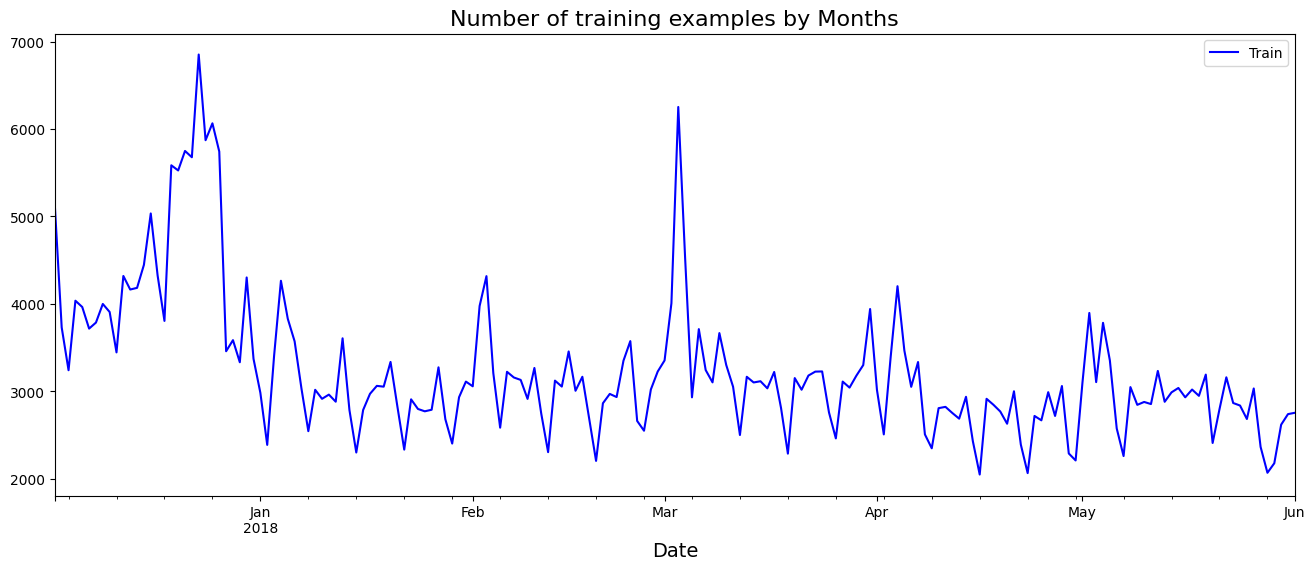

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(16, 6))
train['TransactionDT'].dt.floor('d').value_counts().sort_index().plot(ax=axes, color='b').set_xlabel('Date', fontsize=14)
#test['TransactionDT'].dt.floor('d').value_counts().sort_index().plot(ax=axes, color='skyblue').set_ylabel('Number of training examples', fontsize=14)
axes.set_title('Number of training examples by Months', fontsize=16)
axes.legend(['Train'])

In [ ]:
train.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1

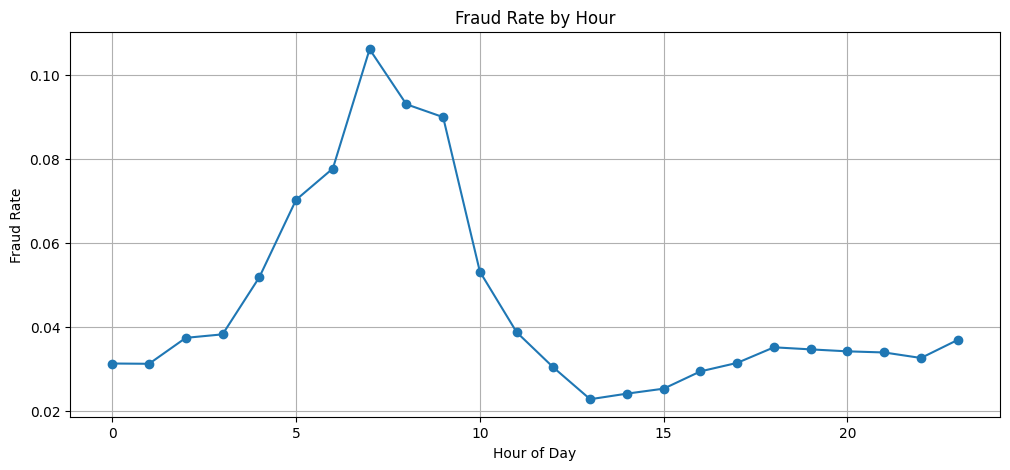

In [ ]:
import matplotlib.pyplot as plt

# tạo feature giờ
train['hour'] = train['TransactionDT'].dt.hour

# tính fraud rate theo giờ
hour_fraud = train.groupby('hour')['isFraud'].mean()

# vẽ biểu đồ
plt.figure(figsize=(12,5))
hour_fraud.plot(kind='line', marker='o')

plt.title('Fraud Rate by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate')
plt.grid(True)

plt.show()

/tmp/ipykernel_15838/1167301452.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


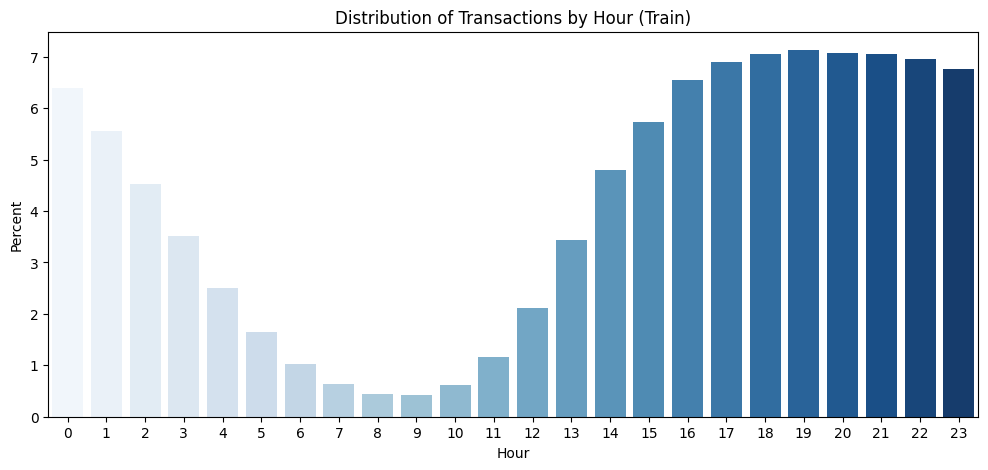

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

percentage = lambda i: len(i) / len(train['hour']) * 100

sns.barplot(
    x=train['hour'],
    y=train['hour'],
    estimator=percentage,
    palette='Blues'
)

plt.ylabel('Percent')
plt.xlabel('Hour')
plt.title('Distribution of Transactions by Hour (Train)')

plt.show()

<Axes: xlabel='hour', ylabel='percentage'>

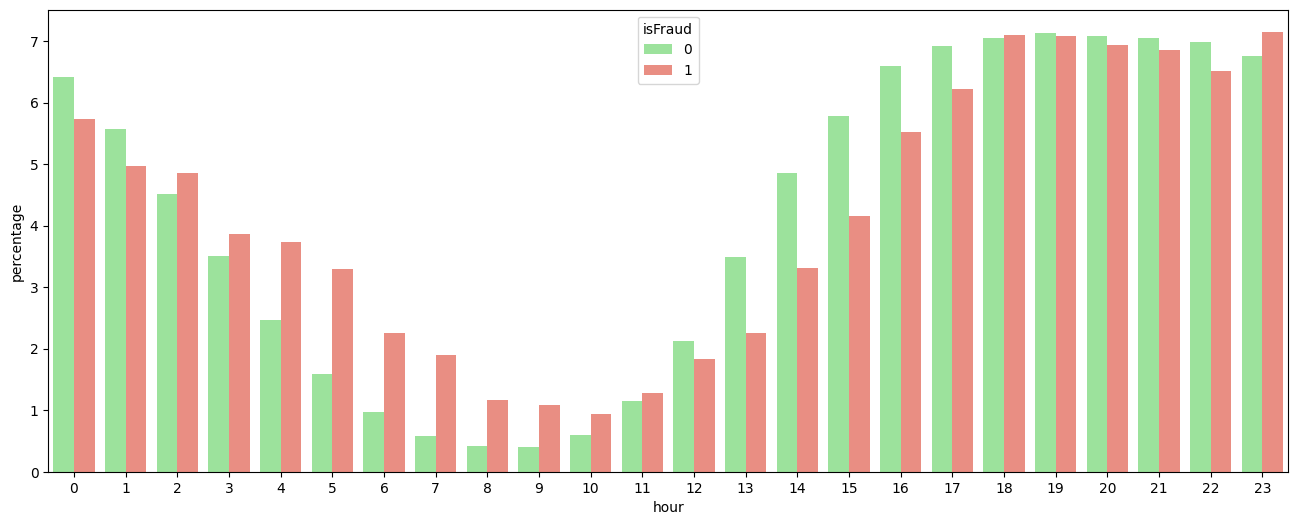

In [ ]:

train_hour = (train.groupby(['isFraud'])['hour']
                     .value_counts(normalize=True)
                     .rename('percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('hour'))

plt.figure(figsize=(16, 6))
sns.barplot(x="hour", y="percentage", hue="isFraud",palette=['#90EE90', '#FA8072'] , data=train_hour)

In [ ]:
def hour_bucket(h):
    if h in [6,7,8,9]:
        return 'high'
    elif h in [3,4,5,10]:
        return 'medium_high'
    elif h in [2,18,23]:
        return 'low'
    else:
        return 'normal'

In [ ]:

train['alertFeature'] = train['hour'].apply(hour_bucket)

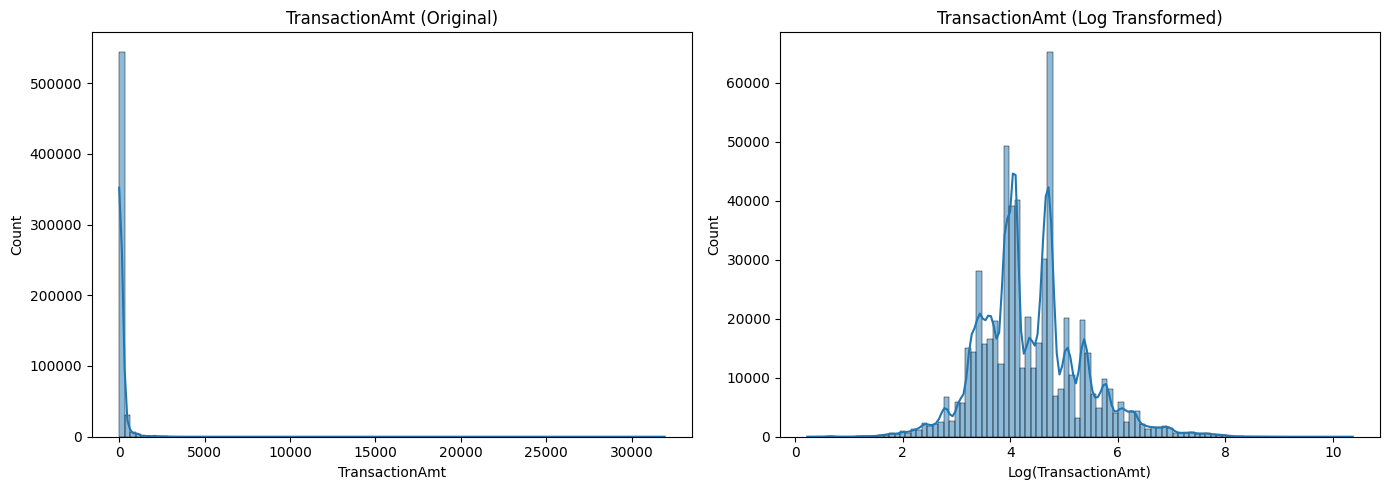

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# tạo log feature
train['TransactionAmt_log'] = np.log1p(train['TransactionAmt'])

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(train['TransactionAmt'], bins=100, kde=True)
plt.title('TransactionAmt (Original)')
plt.xlabel('TransactionAmt')

plt.subplot(1,2,2)
sns.histplot(train['TransactionAmt_log'], bins=100, kde=True)
plt.title('TransactionAmt (Log Transformed)')
plt.xlabel('Log(TransactionAmt)')

plt.tight_layout()
plt.show()

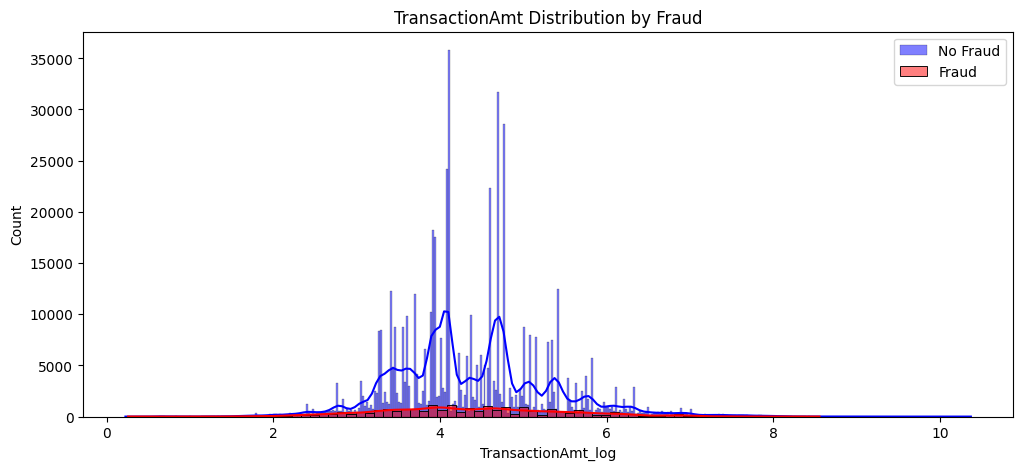

In [ ]:
plt.figure(figsize=(12,5))

sns.histplot(train[train['isFraud']==0]['TransactionAmt_log'],
             color='blue', label='No Fraud', kde=True)

sns.histplot(train[train['isFraud']==1]['TransactionAmt_log'],
             color='red', label='Fraud', kde=True)

plt.legend()
plt.title('TransactionAmt Distribution by Fraud')
plt.show()

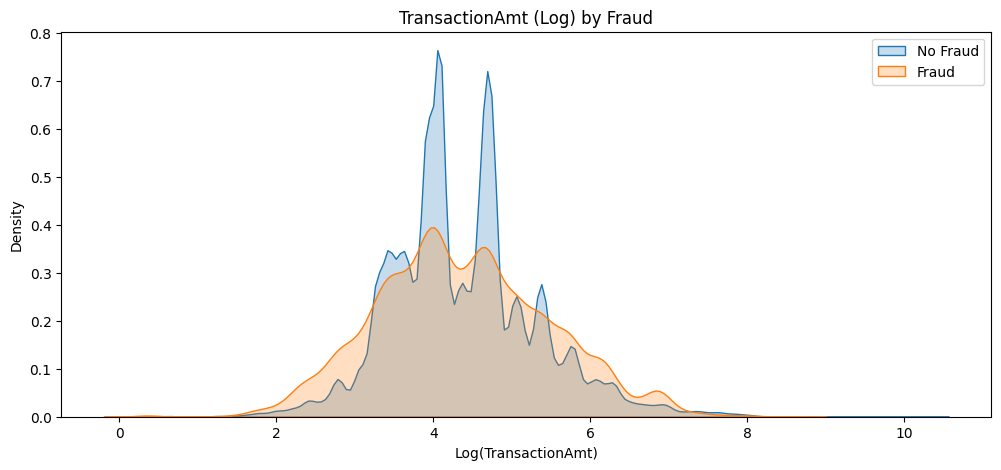

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# log transform
train['TransactionAmt_log'] = np.log1p(train['TransactionAmt'])

plt.figure(figsize=(12,5))

sns.kdeplot(train[train['isFraud']==0]['TransactionAmt_log'],
            label='No Fraud', fill=True)

sns.kdeplot(train[train['isFraud']==1]['TransactionAmt_log'],
            label='Fraud', fill=True)

plt.title('TransactionAmt (Log) by Fraud')
plt.xlabel('Log(TransactionAmt)')
plt.legend()
plt.show()

In [ ]:
train['TransactionAmt'].describe()

,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000


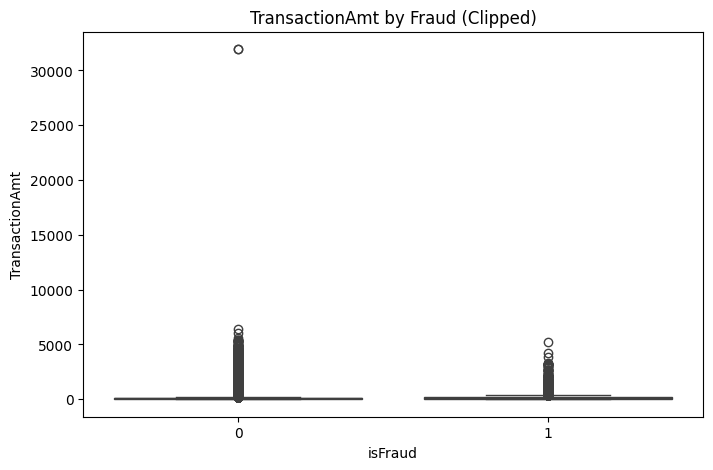

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='isFraud', y='TransactionAmt', data=train)


plt.title('TransactionAmt by Fraud (Clipped)')
plt.show()

In [ ]:
train.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,normal,4.241327
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mas

In [ ]:
train['TransactionAmt'].describe()

,TransactionAmt
count,590540.000000
mean,135.027176
std,239.162522
min,0.251000
25%,43.321000
50%,68.769000
75%,125.000000
max,31937.391000


In [ ]:
train['TransactionAmt_log'].describe()

,TransactionAmt_log
count,590540.000000
mean,4.382960
std,0.937183
min,0.223943
25%,3.791459
50%,4.245190
75%,4.836282
max,10.371564


In [ ]:
import pandas as pd

pd.set_option('display.max_columns', None)

In [ ]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,normal,4.241327
1,2987001,0,2017-12-02 00:00:01,29.0,W,2755,404.0,150.0,mas

In [ ]:
train['ProductCD'].unique()

array(['W', 'H', 'C', 'S', 'R'], dtype=object)

In [ ]:
train.dtypes

,0
TransactionID,int64
isFraud,int64
TransactionDT,datetime64[ns]
TransactionAmt,float64
ProductCD,object
...,...
DeviceType,object
DeviceInfo,object
hour,int32
alertFeature,object


In [ ]:
train.shape

(590540, 437)

In [ ]:
train['M1'].unique()

array(['T', nan, 'F'], dtype=object)

In [ ]:
binary_cols = [col for col in train.columns if train[col].nunique(dropna=True) == 2]

In [ ]:
train[binary_cols]

,isFraud,M1,M2,M3,M5,M6,M7,M8,M9,V1,V14,V41,V65,V88,V107,V305,id_12,id_16,id_27,id_28,id_29,id_35,id_36,id_37,id_38,DeviceType
0,0,T,T,T,F,T,NaN,NaN,NaN,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,NaN,NaN,NaN,T,T,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,T,T,T,F,F,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,T,F,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NotFound,NotFound,NaN,New,NotFound,T,F,T,T,mobile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,0,T,T,T,T,F,F,F,T,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590536,0,T,F,F,F,T,F,F,F,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590537,0,T,F,F,NaN,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
590538,0,T,T,T,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


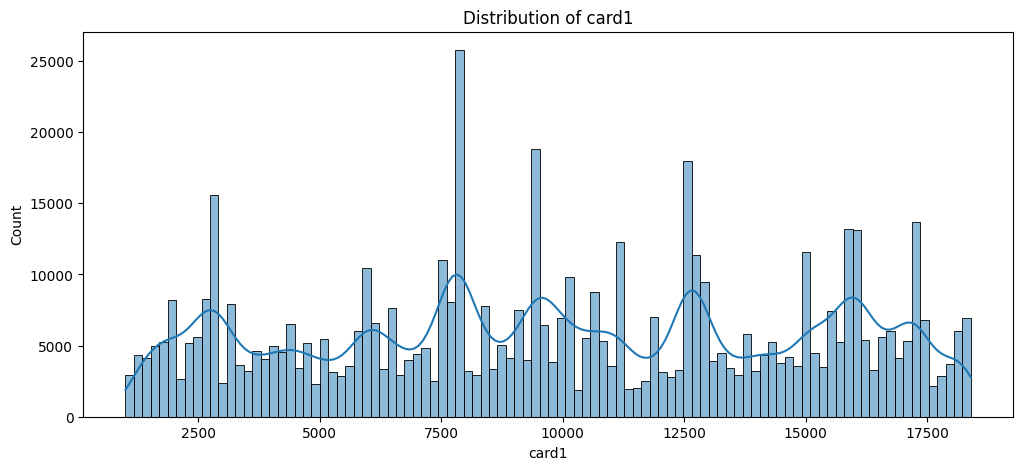

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.histplot(train['card1'], bins=100, kde=True)
plt.title('Distribution of card1')
plt.xlabel('card1')
plt.ylabel('Count')
plt.show()

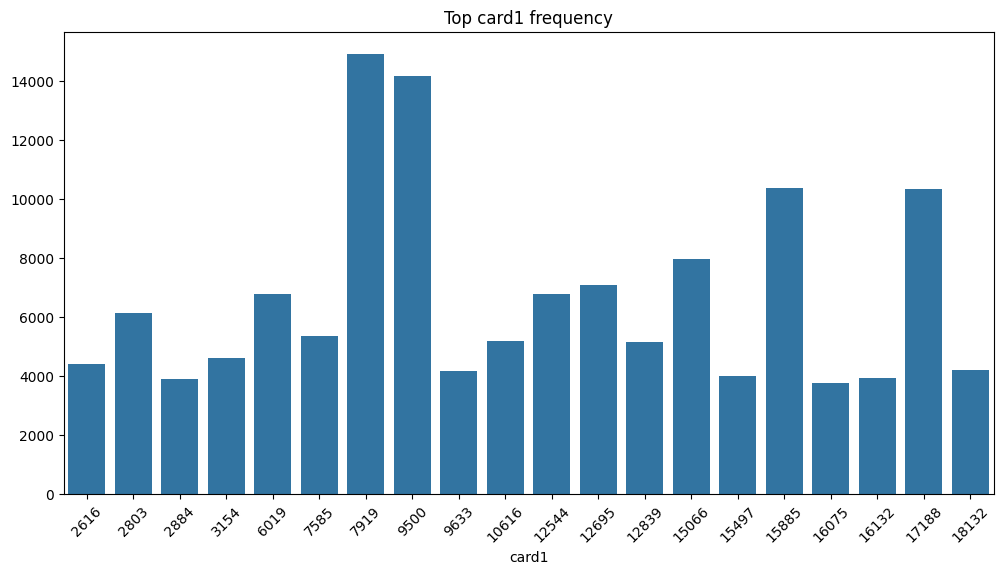

In [ ]:
top = train['card1'].value_counts().head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=top.index, y=top.values)
plt.xticks(rotation=45)
plt.title("Top card1 frequency")
plt.show()

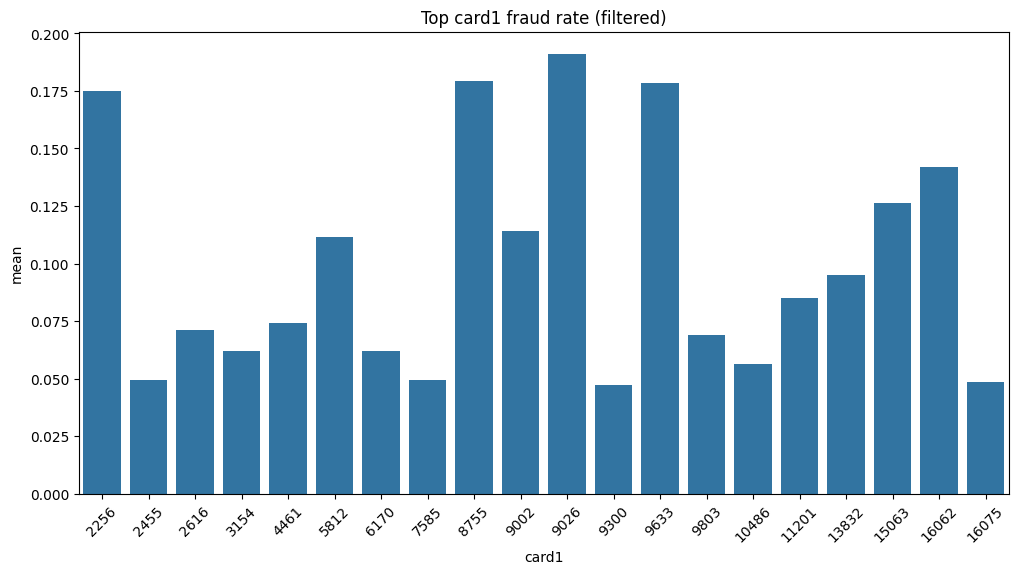

In [ ]:
card1_fraud = train.groupby('card1')['isFraud'].agg(['count','mean'])

# chỉ giữ card có đủ data
card1_fraud = card1_fraud[card1_fraud['count'] > 1000]

card1_fraud = card1_fraud.sort_values('mean', ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(x=card1_fraud.index, y=card1_fraud['mean'])
plt.xticks(rotation=45)
plt.title("Top card1 fraud rate (filtered)")
plt.show()

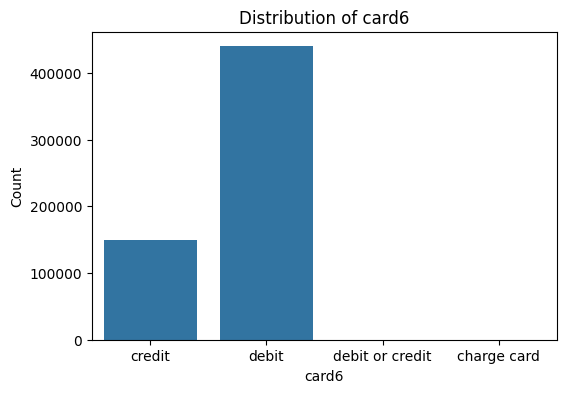

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='card6', data=train)
plt.title('Distribution of card6')
plt.xlabel('card6')
plt.ylabel('Count')
plt.show()

In [ ]:
train['card6'] = train['card6'].replace({
    'debit or credit': 'other',
    'charge card': 'other'
})

In [ ]:
# tỷ lệ fraud của từng nhóm
fraud_rate = train.groupby('card6')['isFraud'].mean()

# số lượng mỗi nhóm
counts = train['card6'].value_counts()

# gộp lại xem cho dễ
summary = pd.concat([fraud_rate, counts], axis=1)
summary.columns = ['fraud_rate', 'count']

print(summary)

        fraud_rate   count
card6                     
credit    0.066785  148986
debit     0.024263  439938
other     0.000000      45


In [ ]:
train['card6'] = train['card6'].replace({'other': 'debit'
})

In [ ]:
# tỷ lệ fraud của từng nhóm
fraud_rate = train.groupby('card6')['isFraud'].mean()

# số lượng mỗi nhóm
counts = train['card6'].value_counts()

# gộp lại xem cho dễ
summary = pd.concat([fraud_rate, counts], axis=1)
summary.columns = ['fraud_rate', 'count']

print(summary)

        fraud_rate   count
card6                     
credit    0.066785  148986
debit     0.024260  439983


In [ ]:
train['id_30'].unique()

array([nan, 'Android 7.0', 'iOS 11.1.2', 'Mac OS X 10_11_6', 'Windows 10',
       'Android', 'Linux', 'iOS 11.0.3', 'Mac OS X 10_7_5',
       'Mac OS X 10_12_6', 'Mac OS X 10_13_1', 'iOS 11.1.0',
       'Mac OS X 10_9_5', 'Windows 7', 'Windows 8.1', 'Mac', 'iOS 10.3.3',
       'Mac OS X 10.12', 'Mac OS X 10_10_5', 'Mac OS X 10_11_5',
       'iOS 9.3.5', 'Android 5.1.1', 'Android 7.1.1', 'Android 6.0',
       'iOS 10.3.1', 'Mac OS X 10.9', 'iOS 11.1.1', 'Windows Vista',
       'iOS 10.3.2', 'iOS 11.0.2', 'Mac OS X 10.11', 'Android 8.0.0',
       'iOS 10.2.0', 'iOS 10.2.1', 'iOS 11.0.0', 'Mac OS X 10.10',
       'Mac OS X 10_12_3', 'Mac OS X 10_12', 'Android 6.0.1', 'iOS',
       'Mac OS X 10.13', 'Mac OS X 10_12_5', 'Mac OS X 10_8_5',
       'iOS 11.0.1', 'iOS 10.0.2', 'Android 5.0.2', 'Windows XP',
       'iOS 11.2.0', 'Mac OS X 10.6', 'Windows 8', 'Mac OS X 10_6_8',
       'Mac OS X 10_11_4', 'Mac OS X 10_12_1', 'iOS 10.1.1',
       'Mac OS X 10_11_3', 'Mac OS X 10_12_4', 'Mac OS X 10

In [ ]:
train['id_31'].unique()

array([nan, 'samsung browser 6.2', 'mobile safari 11.0', 'chrome 62.0',
       'chrome 62.0 for android', 'edge 15.0', 'mobile safari generic',
       'chrome 49.0', 'chrome 61.0', 'edge 16.0', 'safari generic',
       'edge 14.0', 'chrome 56.0 for android', 'firefox 57.0',
       'chrome 54.0 for android', 'mobile safari uiwebview', 'chrome',
       'chrome 62.0 for ios', 'firefox', 'chrome 60.0 for android',
       'mobile safari 10.0', 'chrome 61.0 for android',
       'ie 11.0 for desktop', 'ie 11.0 for tablet', 'mobile safari 9.0',
       'chrome generic', 'other', 'chrome 59.0 for android',
       'firefox 56.0', 'android webview 4.0', 'chrome 55.0', 'opera 49.0',
       'ie', 'chrome 55.0 for android', 'firefox 52.0',
       'chrome 57.0 for android', 'chrome 56.0',
       'chrome 46.0 for android', 'chrome 58.0', 'firefox 48.0',
       'chrome 59.0', 'samsung browser 4.0', 'edge 13.0',
       'chrome 53.0 for android', 'chrome 58.0 for android',
       'chrome 60.0', 'mobile sa

In [ ]:
def clean_os(x):
    if pd.isna(x):
        return x
    x = x.lower()

    if 'android' in x:
        return 'android'
    elif 'ios' in x:
        return 'ios'
    elif 'windows' in x:
        return 'windows'
    elif 'mac' in x:
        return 'mac'
    elif 'linux' in x:
        return 'linux'
    else:
        return 'other'

train['OS'] = train['id_30'].apply(clean_os)

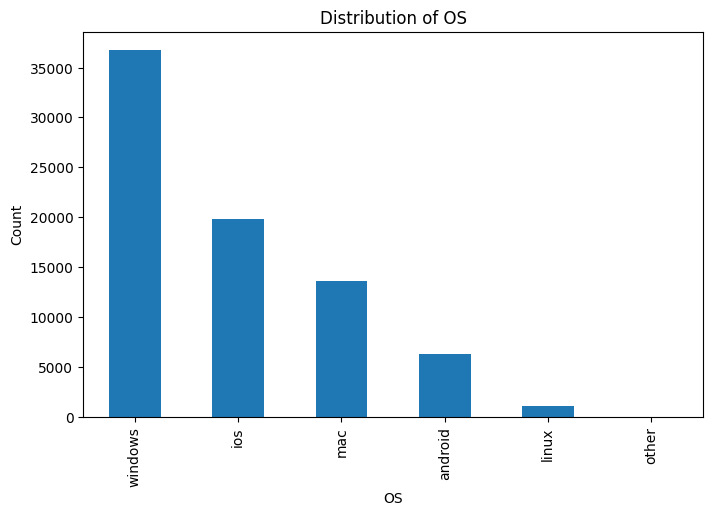

In [ ]:
import matplotlib.pyplot as plt

train['OS'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Distribution of OS')
plt.xlabel('OS')
plt.ylabel('Count')
plt.show()

In [ ]:
train['OS'].value_counts()

,count
OS,
windows,36739
ios,19782
mac,13580
android,6303
linux,1136
other,25


In [ ]:
train['OS'].groupby(train['isFraud']).value_counts()


isFraud  OS     
0        windows    35471
         ios        18542
         mac        13282
         android     5761
         linux       1051
         other         16
1        windows     1268
         ios         1240
         android      542
         mac          298
         linux         85
         other          9
Name: count, dtype: int64

In [ ]:
def clean_browser(x):
    if pd.isna(x):
        return x

    x = x.lower()

    if 'chrome' in x:
        return 'chrome'
    elif 'safari' in x:
        return 'safari'
    elif 'firefox' in x:
        return 'firefox'
    elif 'edge' in x:
        return 'edge'
    elif 'ie' in x:
        return 'ie'
    elif 'opera' in x:
        return 'opera'
    elif 'samsung' in x:
        return 'samsung'
    elif 'android' in x:
        return 'android_webview'
    else:
        return 'other'

train['browser'] = train['id_31'].apply(clean_browser)

In [ ]:
train = train.sort_values('TransactionDT')

n = len(train)

train_val = train.iloc[:int(0.85*n)]
test_df   = train.iloc[int(0.85*n):]

In [ ]:
test_df['isFraud'].value_counts()

,count
isFraud,
0,85498
1,3083


In [ ]:
test_df['isFraud'].mean()

np.float64(0.03480430340592226)

In [ ]:
train_val.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log,OS,browser
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,normal,4.241327,NaN,NaN
1,2987001,0,2017-12-02 00:00:01,29.0,W,2

In [ ]:
test_df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log,OS,browser
501959,3488959,0,2018-05-02 05:18:00,57.950,W,7919,194.0,150.0,mastercard,166.0,debit,143.0,87.0,NaN,NaN,anonymous.com,NaN,150.0,133.0,0.0,0.0,115.0,103.0,0.0,0.0,99.0,0.0,106.0,0.0,584.0,132.0,365.0,365.0,31.0,365.0,31.0,NaN,NaN,NaN,NaN,332.0,0.0,NaN,NaN,NaN,365.0,T,T,F,NaN,NaN,F,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
start = datetime.datetime.strptime('2017-12-01', '%Y-%m-%d')


for df in [train]:

    df['DT_D'] = (df['TransactionDT'] - start).dt.days
    df['DT_W'] = df['DT_D'] // 7
    df['DT_M'] = df['DT_D'] // 30

In [ ]:
train.shape

(590540, 442)

In [ ]:
for df in [train]:
    daily_total = df.groupby('DT_D')['TransactionAmt'].transform('count')
    df['ProductCD_Day_ratio'] = df.groupby(['ProductCD','DT_D'])['TransactionAmt'].transform('count') / daily_total

In [ ]:
print(list(train['DeviceInfo'].unique()))

[nan, 'SAMSUNG SM-G892A Build/NRD90M', 'iOS Device', 'Windows', 'MacOS', 'SM-G930V Build/NRD90M', 'BLADE A602 Build/MRA58K', 'XT1635-02 Build/NPN26.118-22-2', 'Z970', 'SM-N920V Build/NRD90M', 'Redmi Note 4 Build/MMB29M', 'Lenovo PB1-750M Build/S100', 'LT22i Build/6.2.A.1.100', 'rv:52.0', 'SM-G950U Build/NRD90M', 'LG-H872 Build/NRD90U', 'LG-K500 Build/MMB29M', 'SM-P550 Build/MMB29M', 'SM-J700M Build/MMB29K', 'Trident/7.0', 'rv:57.0', 'SAMSUNG SM-G930T Build/NRD90M', 'Blade V6 Plus Build/MRA58K', 'BLL-L23 Build/HUAWEIBLL-L23', 'KYOCERA-C6742A Build/LMY47V', 'F3113 Build/33.2.A.4.70', 'D5306 Build/19.4.A.0.182', 'M4 SS4457 Build/MRA58K', 'SM-G955U Build/NRD90M', 'SM-G610M Build/MMB29K', 'SAMSUNG SM-G935F Build/NRD90M', 'XT1635-01', 'rv:56.0', 'VS500', 'CAM-L03 Build/HUAWEICAM-L03', 'RCT6303W87M7 Build/MRA58K', 'M4 SS4451 Build/LMY47D', 'KFFOWI Build/LVY48F', 'Moto E (4) Build/NMA26.42-19', 'SAMSUNG', 'E2306 Build/26.3.A.1.33', 'Ilium L910 Build/MRA58K', 'GT-I9300', 'LG-H420 Build/LRX21Y',

In [ ]:
def process_device(df):

    # ===== extract raw =====
    df['device_name'] = df['DeviceInfo'].str.split('/', expand=True)[0]
    dn = df['device_name'].fillna('').str.lower()

    # ===== BIG BRANDS =====
    df.loc[dn.str.contains('sm-|samsung|gt-'), 'device_name'] = 'Samsung'
    df.loc[dn.str.contains('iphone|ios|apple'), 'device_name'] = 'Apple'
    df.loc[dn.str.contains('huawei|honor|ale-|was-|bla-|pra-|fig-|vtr-|mha-|ane-'), 'device_name'] = 'Huawei'
    df.loc[dn.str.contains('moto'), 'device_name'] = 'Motorola'
    df.loc[dn.str.contains('lg'), 'device_name'] = 'LG'
    df.loc[dn.str.contains('htc'), 'device_name'] = 'HTC'
    df.loc[dn.str.contains('asus'), 'device_name'] = 'Asus'
    df.loc[dn.str.contains('sony|e[0-9]{4}|d[0-9]{4}'), 'device_name'] = 'Sony'

    # ===== OTHER MAJOR =====
    df.loc[dn.str.contains('redmi|mi |mi-|xiaomi'), 'device_name'] = 'Xiaomi'
    df.loc[dn.str.contains('oneplus|a0001|one a'), 'device_name'] = 'OnePlus'
    df.loc[dn.str.contains('cph'), 'device_name'] = 'Oppo'
    df.loc[dn.str.contains('vivo'), 'device_name'] = 'Vivo'
    df.loc[dn.str.contains('lenovo|yoga|ideatab'), 'device_name'] = 'Lenovo'
    df.loc[dn.str.contains('zte|blade'), 'device_name'] = 'ZTE'
    df.loc[dn.str.contains('hisense'), 'device_name'] = 'Hisense'
    df.loc[dn.str.contains('alcatel|one touch'), 'device_name'] = 'Alcatel'
    df.loc[dn.str.contains('pixel|nexus|google'), 'device_name'] = 'Google'
    df.loc[dn.str.contains('ta-|nokia'), 'device_name'] = 'Nokia'

    # ===== LONG-TAIL =====
    df.loc[dn.str.contains('blu'), 'device_name'] = 'BLU'
    df.loc[dn.str.contains('coolpad'), 'device_name'] = 'Coolpad'
    df.loc[dn.str.contains('infinix'), 'device_name'] = 'Infinix'
    df.loc[dn.str.contains('verykool'), 'device_name'] = 'Verykool'
    df.loc[dn.str.contains('ilium'), 'device_name'] = 'Lanix'
    df.loc[dn.str.contains('neffos'), 'device_name'] = 'TP-Link'
    df.loc[dn.str.contains('bv[0-9]'), 'device_name'] = 'Blackview'

    # ===== AMAZON =====
    df.loc[dn.str.contains('kf|kindle'), 'device_name'] = 'Amazon'

    # ===== OS / BROWSER =====
    df.loc[dn.str.contains('windows|microsoft'), 'device_name'] = 'Microsoft'
    df.loc[dn.str.contains('mac'), 'device_name'] = 'Mac'
    df.loc[dn.str.contains('linux'), 'device_name'] = 'Linux'
    df.loc[dn.str.contains('rv:|trident'), 'device_name'] = 'Browser'

    return df

In [ ]:
train = process_device(train)

In [ ]:
train['device_name'].value_counts()

,count
device_name,
Microsoft,47790
Apple,19783
Mac,12573
Samsung,12091
Browser,11825
...,...
A3-A20,1
Shift Build,1
N9560 Build,1


In [ ]:
train['device_name'].unique()

array([nan, 'Samsung', 'Apple', 'Microsoft', 'Mac', 'ZTE',
       'XT1635-02 Build', 'Z970', 'Xiaomi', 'Lenovo', 'LT22i Build',
       'Browser', 'LG', 'BLL-L23 Build', 'KYOCERA-C6742A Build',
       'F3113 Build', 'Sony', 'M4 SS4457 Build', 'XT1635-01', 'VS500',
       'CAM-L03 Build', 'RCT6303W87M7 Build', 'M4 SS4451 Build', 'Amazon',
       'Motorola', 'Lanix', 'XT1032 Build', 'TRT-L53 Build',
       'Android 6.0.1', 'Google', 'SGP521', 'VS988 Build', 'es-us', 'HTC',
       '7055A Build', 'Huawei', 'Z836BL', 'M4 SS4450 Build', 'Z981 Build',
       'Alcatel', 'F5121 Build', 'R8106', 'Nokia', 'VK810', '5012G Build',
       '5080A Build', 'XT1254 Build', 'Z410', 'P4526A Build', 'XT1565',
       'F3213 Build', 'REX', 'XT1585 Build', 'Edison', 'Hisense',
       'QTASUN1 Build', 'XT1063', 'VS995 Build', 'BAC-L03 Build', 'VS835',
       'CHC-U03 Build', 'Aquaris', 'MOT-A6020l37 Build', '5011A Build',
       'MDDRJS', 'Y635-L03 Build', 'XT1635-01 Build', 'M4 SS4456 Build',
       'BNTV400',

In [ ]:
vc = train['device_name'].value_counts(dropna=True)
top_brands = vc[vc > 100].index

train.loc[
    (~train['device_name'].isin(top_brands)) & (train['device_name'].notna()),
    'device_name'
] = 'Others'

In [ ]:
train['device_name'].value_counts()

,count
device_name,
Microsoft,47790
Apple,19783
Mac,12573
Samsung,12091
Browser,11825
Others,3979
Motorola,2935
LG,2563
Huawei,1442


In [ ]:

train[['D1', 'DT_D']].corr()

,D1,DT_D
D1,1.000000,0.073995
DT_D,0.073995,1.000000


In [ ]:
train.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log,OS,browser,DT_D,DT_W,DT_M,ProductCD_Day_ratio,device_name
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,normal,4.241327,N

In [ ]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log,OS,browser,DT_D,DT_W,DT_M,ProductCD_Day_ratio,device_name
590535,3577535,0,2018-06-01 23:57:27,49.00,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [ ]:
train['D1'].describe()

,D1
count,589271.000000
mean,94.347568
std,157.660387
min,0.000000
25%,0.000000
50%,3.000000
75%,122.000000
max,640.000000


In [ ]:
train['D1'].isnull().sum()

np.int64(1269)

In [ ]:
train.iloc[:, 4:12].nunique()

,0
ProductCD,5
card1,13553
card2,500
card3,114
card4,4
card5,119
card6,2
addr1,332


In [ ]:
train.iloc[:, 5:11].isnull().sum()

,0
card1,0
card2,8933
card3,1565
card4,1577
card5,4259
card6,1571


In [ ]:
train['uid'] = train['card1'].astype(str) +' '+ train['card2'].astype(str)+' '+ train['card3'].astype(str)+' '+train['card4'].astype(str)+' '+ train['card5'].astype(str)+' '+ train['card6'].astype(str) +' '+ train['addr1'].astype(str)+' '+train['addr2'].astype(str)

In [ ]:
train['uid'].nunique()

43069

In [ ]:
train['OS'].isnull().mean()

np.float64(0.868654113184543)

In [ ]:
import hashlib
def device_hash(x):
    cols = ['id_30','id_31','id_32','id_33','DeviceType','DeviceInfo']

    vals = [str(x[c]) for c in cols if pd.notnull(x[c])]

    if len(vals) == 0:
        return np.nan   # 🔥 quan trọng

    return hashlib.sha256('_'.join(vals).encode()).hexdigest()[:15]

In [ ]:
cols = ['id_30','id_31','id_32','id_33','DeviceType','DeviceInfo']

def smart_join(row):
    vals = [str(v) for v in row if pd.notnull(v)]
    if len(vals) == 0:
        return np.nan
    return '_'.join(vals)

train['device_hash'] = train[cols].apply(smart_join, axis=1)

In [ ]:
train['uid_device_nunique'] = train.groupby('uid')['device_hash'].transform('nunique')

In [ ]:
train['device_uid_nunique'] = train.groupby('device_hash')['uid'].transform('nunique')

In [ ]:
train['decimal_digit'] = (
    train['TransactionAmt']
    .round(3)
    .astype(str)
    .str.split('.')
    .str[1]
    .str.rstrip('0')
    .str.len()
    .fillna(0)
)

In [ ]:
train['dow'] = train['TransactionDT'].dt.dayofweek

In [ ]:
cols = [f'D{i}' for i in range(1, 16)]

missing_ratio = train[cols].isnull().mean().sort_values(ascending=False)

print(missing_ratio)

D7     0.934099
D13    0.895093
D14    0.894695
D12    0.890410
D6     0.876068
D8     0.873123
D9     0.873123
D5     0.524674
D2     0.475492
D11    0.472935
D3     0.445149
D4     0.286047
D15    0.150901
D10    0.128733
D1     0.002149
dtype: float64


In [ ]:
for t in ['D1','D2','D4','D6','D10','D11','D12','D14','D15']:
  train[t+'_revised'] = train[t]/train.groupby('DT_W')[t].transform('max')

for t in ['D3','D5','D7','D8','D13']:
  train[t+'_revised'] = train[t]/train.groupby('DT_M')[t].transform('max')


In [ ]:
train['email_domain_comp'] = np.where(
    train['P_emaildomain'].isnull() & train['R_emaildomain'].isnull(), -1,
    np.where(
        train['P_emaildomain'] == train['R_emaildomain'], 1, 0
    )
)

In [ ]:
v_cols = [f'V{i}' for i in range(1, 340)]

missing_ratio = train[v_cols].isnull().mean().sort_values(ascending=False)

missing_ratio.tail(20)

,0
V291,0.00002
V285,0.00002
V287,0.00002
V290,0.00002
V284,0.00002
V279,0.00002
V280,0.00002
V286,0.00002
V310,0.00002
V309,0.00002


In [ ]:

cat_cols = [
    'ProductCD',
    'card1','card2','card3','card4','card5','card6',
    'addr1','addr2',
    'P_emaildomain','R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'DeviceType','DeviceInfo',

    # thêm mới
    'OS','browser','alertFeature','device_name','uid'
]

# id_12 → id_38
cat_cols += [f'id_{i}' for i in range(12, 39)]

# chỉ giữ cột tồn tại
cat_cols = [col for col in cat_cols if col in train.columns]

In [ ]:
binary_cols = []
multi_cols = []

for col in cat_cols:
    if col == 'uid':
        continue

    nunique = train[col].nunique(dropna=True)

    if nunique == 2:
        binary_cols.append(col)
    elif nunique > 2:
        multi_cols.append(col)

In [ ]:
binary_cols = []
multi_cols = []

for col in cat_cols:
    if col == 'uid':
        continue

    nunique = train[col].nunique(dropna=True)

    if nunique == 2:
        binary_cols.append(col)
    elif nunique > 2:
        multi_cols.append(col)

In [ ]:
for col in multi_cols:
    freq = train[col].value_counts()
    train[col + '_freq'] = train[col].map(freq)

In [ ]:
train.head(5)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,hour,alertFeature,TransactionAmt_log,OS,browser,DT_D,DT_W,DT_M,ProductCD_Day_ratio,device_name,uid,device_hash,uid_device_nunique,device_uid_nunique,decimal_digit,dow,D1_revised,D2_revised,D4_revised,D6_revised,D10_revised,D11_revised,D12_revised,D14_revised,D15_revised,D3_revised,D5_revised,D7_revised,D8_revised,D13_revised,email_domain_comp,ProductCD_freq,card1_freq,card2_freq,card3_freq,card4_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,DeviceInfo_freq,OS_freq,browser_freq,alertFeature_freq,device_name_freq,id_13_freq,id_14_freq,id_15_freq,id_17_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_23_freq,id_24_freq,id_25_freq,id_26_freq,id_30_freq,id_31_freq,id_32_freq,id_33_freq,id_34_freq
0,2987000,0,2017-12-02 00:00:00,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [ ]:
for col in train.columns:
    miss_total = train[col].isnull().mean()

    miss_fraud1 = train[train.isFraud == 1][col].isnull().mean()
    miss_fraud0 = train[train.isFraud == 0][col].isnull().mean()

    diff = abs(miss_fraud1 - miss_fraud0)

    if 0.05 < miss_total < 0.8 and diff > 0.25:
        train[col + '_isna'] = train[col].isnull().astype(int)

/tmp/ipykernel_15838/996375124.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_isna'] = train[col].isnull().astype(int)
/tmp/ipykernel_15838/996375124.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_isna'] = train[col].isnull().astype(int)
/tmp/ipykernel_15838/996375124.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. T

In [ ]:
cols_0_433 = train.columns[:434]
missing_ratio = train[cols_0_433].isnull().mean()

drop_cols = missing_ratio[missing_ratio > 0.8].index.tolist()

train = train.drop(columns=drop_cols)

In [ ]:
train.shape

(590540, 574)

In [ ]:
drop_cols = [
    'TransactionID',
    'TransactionAmt',
    'DeviceInfo',
    'DT_D','DT_W','DT_M','hour'
]

# D1 → D13
drop_cols += [f'D{i}' for i in range(1, 14)]

# chỉ drop cột tồn tại
drop_cols = [col for col in drop_cols if col in train.columns]

train = train.drop(columns=drop_cols)

In [ ]:
train = train.sort_values('TransactionDT')

n = len(train)
split = int(0.8 * n)

X_train = train.iloc[:split].drop(columns=['isFraud'])
y_train = train.iloc[:split]['isFraud']

X_valid = train.iloc[split:].drop(columns=['isFraud'])
y_valid = train.iloc[split:]['isFraud']

In [ ]:
X_valid.drop(columns='TransactionDT')
X_train.drop(columns='TransactionDT')

,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_15,id_16,id_17,id_19,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,alertFeature,TransactionAmt_log,OS,browser,ProductCD_Day_ratio,device_name,uid,device_hash,uid_device_nunique,device_uid_nunique,decimal_digit,dow,D1_revised,D2_revised,D4_revised,D6_revised,D10_revised,D11_revised,D12_revised,D14_revised,D15_revised,D3_revised,D5_revised,D7_revised,D8_revised,D13_revised,email_domain_comp,ProductCD_freq,card1_freq,card2_freq,card3_freq,card4_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,DeviceInfo_freq,OS_freq,browser_freq,alertFeature_freq,device_name_freq,id_13_freq,id_14_freq,id_15_freq,id_17_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_23_freq,id_24_freq,id_25_freq,id_26_freq,id_30_freq,id_31_freq,id_32_freq,id_33_freq,id_34_freq,addr1_isna,addr2_isna,R_emaildomain_isna,M6_isna,V167_isna,V168_isna,V169_isna,V170_isna,V171_isna,V172_isna,V173_isna,V174_isna,V175_isna,V176_isna,V177_isna,V178_isna,V179_isna,V180_isna,V181_isna,V182_isna,V183_isna,V184_isna,V185_isna,V186_isna,V187_isna,V188_isna,V189_isna,V190_isna,V191_isna,V192_isna,V193_isna,V194_isna,V195_isna,V196_isna,V197_isna,V198_isna,V199_isna,V200_isna,V201_isna,V202_isna,V203_isna,V204_isna,V205_isna,V206_isna,V207_isna,V208_isna,V209_isna,V210_isna,V211_isna,V212_isna,V213_isna,V214_isna,V215_isna,V216_isna,V217_isna,V218_isna,V219_isna,V220_isna,V221_isna,V222_isna,V223_isna,V224_isna,V225_isna,V226_isna,V227_isna,V228_isna,V229_isna,V230_isna,V231_isna,V232_isna,V233_isna,V234_isna,V235_isna,V236_isna,V237_isna,V238_isna,V239_isna,V240_isna,V241_isna,V242_isna,V243_isna,V244_isna,V245_isna,V246_isna,V247_isna,V248_isna,V249_isna,V250_isna,V251_isna,V252_isna,V253_isna,V254_isna,V255_isna,V256_isna,V257_isna,V258_isna,V259_isna,V260_isna,V261_isna,V262_isna,V263_isna,V264_isna,V265_isna,V266_isna,V267_isna,V268_isna,V269_isna,V270_isna,V271_isna,V272_isna,V273_isna,V274_isna,V275_isna,V276_isna,V277_isna,V278_isna,id_01_isna,id_02_isna,id_05_isna,id_06_isna,id_11_isna,id_12_isna,id_13_isna,id_15_isna,id_16_isna,id_17_isna,id_19_isna,id_20_isna,id_28_isna,id_29_isna,id_31_isna,id_35_isna,id_36_isna,id_37_isna,id_38_isna,DeviceType_isna,browser_isna,device_hash_isna,device_uid_nunique_isna,addr1_freq_isna,addr2_freq_isna,R_emaildomain_freq_isna,browser_freq_isna,id_13_freq_isna,id_15_freq_isna,id_17_freq_isna,id_19_freq_isna,id_20_freq_isna,id_31_freq_isna
0

In [ ]:
train.head()

,isFraud,TransactionDT,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_15,id_16,id_17,id_19,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,alertFeature,TransactionAmt_log,OS,browser,ProductCD_Day_ratio,device_name,uid,device_hash,uid_device_nunique,device_uid_nunique,decimal_digit,dow,D1_revised,D2_revised,D4_revised,D6_revised,D10_revised,D11_revised,D12_revised,D14_revised,D15_revised,D3_revised,D5_revised,D7_revised,D8_revised,D13_revised,email_domain_comp,ProductCD_freq,card1_freq,card2_freq,card3_freq,card4_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,DeviceInfo_freq,OS_freq,browser_freq,alertFeature_freq,device_name_freq,id_13_freq,id_14_freq,id_15_freq,id_17_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_23_freq,id_24_freq,id_25_freq,id_26_freq,id_30_freq,id_31_freq,id_32_freq,id_33_freq,id_34_freq,addr1_isna,addr2_isna,R_emaildomain_isna,M6_isna,V167_isna,V168_isna,V169_isna,V170_isna,V171_isna,V172_isna,V173_isna,V174_isna,V175_isna,V176_isna,V177_isna,V178_isna,V179_isna,V180_isna,V181_isna,V182_isna,V183_isna,V184_isna,V185_isna,V186_isna,V187_isna,V188_isna,V189_isna,V190_isna,V191_isna,V192_isna,V193_isna,V194_isna,V195_isna,V196_isna,V197_isna,V198_isna,V199_isna,V200_isna,V201_isna,V202_isna,V203_isna,V204_isna,V205_isna,V206_isna,V207_isna,V208_isna,V209_isna,V210_isna,V211_isna,V212_isna,V213_isna,V214_isna,V215_isna,V216_isna,V217_isna,V218_isna,V219_isna,V220_isna,V221_isna,V222_isna,V223_isna,V224_isna,V225_isna,V226_isna,V227_isna,V228_isna,V229_isna,V230_isna,V231_isna,V232_isna,V233_isna,V234_isna,V235_isna,V236_isna,V237_isna,V238_isna,V239_isna,V240_isna,V241_isna,V242_isna,V243_isna,V244_isna,V245_isna,V246_isna,V247_isna,V248_isna,V249_isna,V250_isna,V251_isna,V252_isna,V253_isna,V254_isna,V255_isna,V256_isna,V257_isna,V258_isna,V259_isna,V260_isna,V261_isna,V262_isna,V263_isna,V264_isna,V265_isna,V266_isna,V267_isna,V268_isna,V269_isna,V270_isna,V271_isna,V272_isna,V273_isna,V274_isna,V275_isna,V276_isna,V277_isna,V278_isna,id_01_isna,id_02_isna,id_05_isna,id_06_isna,id_11_isna,id_12_isna,id_13_isna,id_15_isna,id_16_isna,id_17_isna,id_19_isna,id_20_isna,id_28_isna,id_29_isna,id_31_isna,id_35_isna,id_36_isna,id_37_isna,id_38_isna,DeviceType_isna,browser_isna,device_hash_isna,device_uid_nunique_isna,addr1_freq_isna,addr2_freq_isna,R_emaildomain_freq_isna,browser_freq_isna,id_13_freq_isna,id_15_freq_isna,id_17_freq_isna,id_19_freq_isna,id_20_freq_

In [ ]:
y_train.head()

,isFraud
0,0
1,0
2,0
3,0
4,0


In [ ]:
y_train.describe()

,isFraud
count,472432.000000
mean,0.035135
std,0.184122
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
!pip install lightgbm

In [ ]:
cols = X_train.select_dtypes(include=['datetime64[ns]']).columns

X_train = X_train.drop(columns=cols)
X_valid = X_valid.drop(columns=cols)

In [ ]:
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        vals = X_train[col].dropna().unique()
        mapping = {v: i for i, v in enumerate(vals)}

        X_train[col] = X_train[col].map(mapping)
        X_valid[col] = X_valid[col].map(mapping)

In [ ]:
X_train = X_train.fillna(0)
X_valid = X_valid.fillna(0)

In [ ]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

model = LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=5,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric='auc',
    callbacks=[
        early_stopping(100),
        log_evaluation(100)
    ]
)

[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.474277 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 32354
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.916273	valid_0's binary_logloss: 0.119708
[200]	valid_0's auc: 0.921784	valid_0's binary_logloss: 0.110705
[300]	valid_0's auc: 0.924311	valid_0's binary_logloss: 0.104993
[400]	valid_0's auc: 0.924969	valid_0's binary_logloss: 0.100435
[500]	valid_0's auc: 0.924964	valid_0's binary_logloss: 0.0970629
Early stopping, best iteration is:
[407]	valid_0's

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
               num_leaves=64, random_state=42, reg_alpha=0.1, reg_lambda=0.1,
               scale_pos_weight=5, subsample=0.8)

In [ ]:
pred_proba = model.predict_proba(X_valid, num_iteration=model.best_iteration_)[:,1]

In [ ]:
pred_label = (pred_proba > 0.1).astype(int)

In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

auc = roc_auc_score(y_valid, pred_proba)
precision = precision_score(y_valid, pred_label)
recall = recall_score(y_valid, pred_label)
f1 = f1_score(y_valid, pred_label)

print("AUC:", auc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

AUC: 0.9251291293462641
Precision: 0.18830064618523976
Recall: 0.8174212598425197
F1: 0.3060904818944071


In [ ]:
train.shape

(590540, 560)

In [ ]:
train.head()

,isFraud,TransactionDT,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_15,id_16,id_17,id_19,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,alertFeature,TransactionAmt_log,OS,browser,ProductCD_Day_ratio,device_name,uid,device_hash,uid_device_nunique,device_uid_nunique,decimal_digit,dow,D1_revised,D2_revised,D4_revised,D6_revised,D10_revised,D11_revised,D12_revised,D14_revised,D15_revised,D3_revised,D5_revised,D7_revised,D8_revised,D13_revised,email_domain_comp,ProductCD_freq,card1_freq,card2_freq,card3_freq,card4_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,DeviceInfo_freq,OS_freq,browser_freq,alertFeature_freq,device_name_freq,id_13_freq,id_14_freq,id_15_freq,id_17_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_23_freq,id_24_freq,id_25_freq,id_26_freq,id_30_freq,id_31_freq,id_32_freq,id_33_freq,id_34_freq,addr1_isna,addr2_isna,R_emaildomain_isna,M6_isna,V167_isna,V168_isna,V169_isna,V170_isna,V171_isna,V172_isna,V173_isna,V174_isna,V175_isna,V176_isna,V177_isna,V178_isna,V179_isna,V180_isna,V181_isna,V182_isna,V183_isna,V184_isna,V185_isna,V186_isna,V187_isna,V188_isna,V189_isna,V190_isna,V191_isna,V192_isna,V193_isna,V194_isna,V195_isna,V196_isna,V197_isna,V198_isna,V199_isna,V200_isna,V201_isna,V202_isna,V203_isna,V204_isna,V205_isna,V206_isna,V207_isna,V208_isna,V209_isna,V210_isna,V211_isna,V212_isna,V213_isna,V214_isna,V215_isna,V216_isna,V217_isna,V218_isna,V219_isna,V220_isna,V221_isna,V222_isna,V223_isna,V224_isna,V225_isna,V226_isna,V227_isna,V228_isna,V229_isna,V230_isna,V231_isna,V232_isna,V233_isna,V234_isna,V235_isna,V236_isna,V237_isna,V238_isna,V239_isna,V240_isna,V241_isna,V242_isna,V243_isna,V244_isna,V245_isna,V246_isna,V247_isna,V248_isna,V249_isna,V250_isna,V251_isna,V252_isna,V253_isna,V254_isna,V255_isna,V256_isna,V257_isna,V258_isna,V259_isna,V260_isna,V261_isna,V262_isna,V263_isna,V264_isna,V265_isna,V266_isna,V267_isna,V268_isna,V269_isna,V270_isna,V271_isna,V272_isna,V273_isna,V274_isna,V275_isna,V276_isna,V277_isna,V278_isna,id_01_isna,id_02_isna,id_05_isna,id_06_isna,id_11_isna,id_12_isna,id_13_isna,id_15_isna,id_16_isna,id_17_isna,id_19_isna,id_20_isna,id_28_isna,id_29_isna,id_31_isna,id_35_isna,id_36_isna,id_37_isna,id_38_isna,DeviceType_isna,browser_isna,device_hash_isna,device_uid_nunique_isna,addr1_freq_isna,addr2_freq_isna,R_emaildomain_freq_isna,browser_freq_isna,id_13_freq_isna,id_15_freq_isna,id_17_freq_isna,id_19_freq_isna,id_20_freq_

In [ ]:
X_train.head()

,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,id_01,id_02,id_05,id_06,id_11,id_12,id_13,id_15,id_16,id_17,id_19,id_20,id_28,id_29,id_31,id_35,id_36,id_37,id_38,DeviceType,alertFeature,TransactionAmt_log,OS,browser,ProductCD_Day_ratio,device_name,uid,device_hash,uid_device_nunique,device_uid_nunique,decimal_digit,dow,D1_revised,D2_revised,D4_revised,D6_revised,D10_revised,D11_revised,D12_revised,D14_revised,D15_revised,D3_revised,D5_revised,D7_revised,D8_revised,D13_revised,email_domain_comp,ProductCD_freq,card1_freq,card2_freq,card3_freq,card4_freq,card5_freq,addr1_freq,addr2_freq,P_emaildomain_freq,R_emaildomain_freq,M4_freq,DeviceInfo_freq,OS_freq,browser_freq,alertFeature_freq,device_name_freq,id_13_freq,id_14_freq,id_15_freq,id_17_freq,id_18_freq,id_19_freq,id_20_freq,id_21_freq,id_22_freq,id_23_freq,id_24_freq,id_25_freq,id_26_freq,id_30_freq,id_31_freq,id_32_freq,id_33_freq,id_34_freq,addr1_isna,addr2_isna,R_emaildomain_isna,M6_isna,V167_isna,V168_isna,V169_isna,V170_isna,V171_isna,V172_isna,V173_isna,V174_isna,V175_isna,V176_isna,V177_isna,V178_isna,V179_isna,V180_isna,V181_isna,V182_isna,V183_isna,V184_isna,V185_isna,V186_isna,V187_isna,V188_isna,V189_isna,V190_isna,V191_isna,V192_isna,V193_isna,V194_isna,V195_isna,V196_isna,V197_isna,V198_isna,V199_isna,V200_isna,V201_isna,V202_isna,V203_isna,V204_isna,V205_isna,V206_isna,V207_isna,V208_isna,V209_isna,V210_isna,V211_isna,V212_isna,V213_isna,V214_isna,V215_isna,V216_isna,V217_isna,V218_isna,V219_isna,V220_isna,V221_isna,V222_isna,V223_isna,V224_isna,V225_isna,V226_isna,V227_isna,V228_isna,V229_isna,V230_isna,V231_isna,V232_isna,V233_isna,V234_isna,V235_isna,V236_isna,V237_isna,V238_isna,V239_isna,V240_isna,V241_isna,V242_isna,V243_isna,V244_isna,V245_isna,V246_isna,V247_isna,V248_isna,V249_isna,V250_isna,V251_isna,V252_isna,V253_isna,V254_isna,V255_isna,V256_isna,V257_isna,V258_isna,V259_isna,V260_isna,V261_isna,V262_isna,V263_isna,V264_isna,V265_isna,V266_isna,V267_isna,V268_isna,V269_isna,V270_isna,V271_isna,V272_isna,V273_isna,V274_isna,V275_isna,V276_isna,V277_isna,V278_isna,id_01_isna,id_02_isna,id_05_isna,id_06_isna,id_11_isna,id_12_isna,id_13_isna,id_15_isna,id_16_isna,id_17_isna,id_19_isna,id_20_isna,id_28_isna,id_29_isna,id_31_isna,id_35_isna,id_36_isna,id_37_isna,id_38_isna,DeviceType_isna,browser_isna,device_hash_isna,device_uid_nunique_isna,addr1_freq_isna,addr2_freq_isna,R_emaildomain_freq_isna,browser_freq_isna,id_13_freq_isna,id_15_freq_isna,id_17_freq_isna,id_19_freq_isna,id_20_freq_isna,id_31_freq_isna
0